In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import einsum
from jaxtyping import Float
from pydantic import ConfigDict
from pydantic.dataclasses import dataclass
from tqdm.auto import tqdm

from src.config.base import ConfigMethodsMixin
from src.data.base import DataConfig
from src.data.dataloading import DataLoaderConfig
from src.data.unity_gaussian_mixture.config import UnityGaussianMixtureDatasetConfig
from src.method.latent_generation.config import (
    LatentGenerationLossConfig,
    LatentGenerationMethodConfig,
    LatentGenerationModelConfig,
    MLELatentNoiseWeightConfig,
)
from src.model.mlp import StackedResidualMLPConfig
from src.model.time_conditioning import TimeConditioningConfig
from src.utils import set_seed

SEED = 42

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
print("seed:", SEED)

device: cuda
seed: 42


In [2]:
@dataclass(
    kw_only=True,
    config=ConfigDict(
        arbitrary_types_allowed=True,
        extra="forbid",
    ),
)
class ExperimentConfig(ConfigMethodsMixin):
    method_config: LatentGenerationMethodConfig
    lr: float
    train_epochs: int
    log_every_epochs: int
    grad_clip: float


dataset_config = UnityGaussianMixtureDatasetConfig(
    num_modes=5,
    ambient_dim=32,
    mode_std=0.1,
    ring_radius_in_zscore=1.5,
    scale=1.0,
    offset_norm=0.0,
    embed_seed=7,
    train_size=2048 * 128,
    val_size=2048 * 16,
)

dataloader_config = DataLoaderConfig(
    batch_size=2048,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=True,
)
data_config = DataConfig(
    seed=SEED,
    dataset_config=dataset_config,
    trainloader_config=dataloader_config,
    valloader_config=dataloader_config,
)

encoder_config = StackedResidualMLPConfig.initialize(
    layer_dims=[dataset_config.ambient_dim, 256, 256, 256, dataset_config.ambient_dim],
    time_conditioning_config=TimeConditioningConfig(
        min_t_lambda=0.01,
        max_t_lambda=1.0,
        embedding_dim=256,
    ),
)

decoder_config = StackedResidualMLPConfig.initialize(
    layer_dims=[dataset_config.ambient_dim, 256, 256, dataset_config.ambient_dim],
)

config = ExperimentConfig(
    method_config=LatentGenerationMethodConfig(
        model=LatentGenerationModelConfig(
            encoder_config=encoder_config,
            decoder_config=decoder_config,
            latent_shape=(dataset_config.ambient_dim,),
        ),
        loss=LatentGenerationLossConfig(
            t_min=0.05,
            noise_weight=MLELatentNoiseWeightConfig(),
            reconstruction_weight=10.0,
            cycle_data_weight=2.0,
            cycle_prior_weight=1.0,
            denoising_weight=0.0,
            score_weight=1.0,
        ),
    ),
    lr=3e-4,
    train_epochs=24,
    log_every_epochs=1,
    grad_clip=1.0,
)
config.visualize()

In [3]:
def project_to_plane(
    points_hd: Float[torch.Tensor, "batch ambient_dim"],
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    dataset_config: UnityGaussianMixtureDatasetConfig,
) -> Float[torch.Tensor, "batch plane_dim"]:
    displacement = dataset_config.get_displacement().to(device=points_hd.device, dtype=points_hd.dtype)
    centered = points_hd - displacement
    return einsum(
        centered,
        basis,
        "batch ambient_dim, ambient_dim plane_dim -> batch plane_dim",
    ) / dataset_config.scale


def orthogonal_residual(
    points_hd: Float[torch.Tensor, "batch ambient_dim"],
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    dataset_config: UnityGaussianMixtureDatasetConfig,
) -> Float[torch.Tensor, "batch ambient_dim"]:
    displacement = dataset_config.get_displacement().to(device=points_hd.device, dtype=points_hd.dtype)
    projected = project_to_plane(points_hd, basis, dataset_config)
    lifted = einsum(
        projected,
        basis,
        "batch plane_dim, ambient_dim plane_dim -> batch ambient_dim",
    )
    lifted = dataset_config.scale * lifted + displacement
    return points_hd - lifted


basis = data_config.dataset_config.get_basis().to(DEVICE)
train_loader = data_config.get_trainloader()
val_loader = data_config.get_valloader()
preview_batch = next(iter(val_loader)).to(DEVICE)
preview_batch.x_hd.shape, preview_batch.x_2d.shape

(torch.Size([2048, 32]), torch.Size([2048, 2]))

In [4]:
def collect_metrics(
    config: ExperimentConfig,
    data_config: DataConfig,
    val_loader: torch.utils.data.DataLoader,
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    model: nn.Module,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    with torch.no_grad():
        batch = next(iter(val_loader)).to(device)
        eval_size = int(batch.x_hd.shape[0])
        x_true = batch.data()
        y_true = model.encode(x=x_true)
        x_recon = model.decode(y=y_true)
        z = torch.randn(
            eval_size,
            *config.method_config.model.latent_shape,
            device=device,
        )
        x_gen = model.decode(y=z)
        recon_mse = F.mse_loss(x_recon, x_true).item()
        recon_plane_mse = F.mse_loss(project_to_plane(x_recon, basis, data_config.dataset_config), batch.x_2d).item()
        recon_offplane = orthogonal_residual(x_recon, basis, data_config.dataset_config).norm(dim=-1).mean().item()
        gen_offplane = orthogonal_residual(x_gen, basis, data_config.dataset_config).norm(dim=-1).mean().item()
        gen_radius = project_to_plane(x_gen, basis, data_config.dataset_config).norm(dim=-1).mean().item()
    model.train()
    return {
        "recon_mse": recon_mse,
        "recon_plane_mse": recon_plane_mse,
        "recon_offplane": recon_offplane,
        "gen_offplane": gen_offplane,
        "gen_radius": gen_radius,
    }


def train_experiment(
    config: ExperimentConfig,
    data_config: DataConfig,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    model: nn.Module,
    device: torch.device,
) -> dict[str, list[float]]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    state = config.method_config.initialize_state()
    steps_per_epoch = len(train_loader)

    history: dict[str, list[float]] = {
        "epoch": [],
        "total_loss": [],
        "reconstruction_loss": [],
        "score_loss": [],
        "recon_mse": [],
        "recon_plane_mse": [],
        "recon_offplane": [],
        "gen_offplane": [],
        "gen_radius": [],
    }

    progress_bar = tqdm(
        range(1, config.train_epochs + 1),
        desc="training",
        unit="epoch",
    )
    for epoch in progress_bar:
        epoch_total_loss = 0.0
        epoch_reconstruction_loss = 0.0
        epoch_score_loss = 0.0

        for batch_index, batch in enumerate(train_loader, start=1):
            batch = batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            output = state.compute_losses(model=model, batch=batch)
            weighted_loss_terms = dict(output.weighted_loss_terms)
            total_loss = sum(weighted_loss_terms.values())

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
            optimizer.step()

            epoch_total_loss += float(total_loss.item())
            epoch_reconstruction_loss += float(weighted_loss_terms["reconstruction"].item())
            epoch_score_loss += float(weighted_loss_terms["score"].item())

        if epoch == 1 or epoch % config.log_every_epochs == 0 or epoch == config.train_epochs:
            metrics = collect_metrics(
                config=config,
                data_config=data_config,
                val_loader=val_loader,
                basis=basis,
                model=model,
                device=device,
            )
            history["epoch"].append(epoch)
            history["total_loss"].append(epoch_total_loss / steps_per_epoch)
            history["reconstruction_loss"].append(epoch_reconstruction_loss / steps_per_epoch)
            history["score_loss"].append(epoch_score_loss / steps_per_epoch)
            history["recon_mse"].append(metrics["recon_mse"])
            history["recon_plane_mse"].append(metrics["recon_plane_mse"])
            history["recon_offplane"].append(metrics["recon_offplane"])
            history["gen_offplane"].append(metrics["gen_offplane"])
            history["gen_radius"].append(metrics["gen_radius"])
            progress_bar.set_postfix(
                loss=f"{history['total_loss'][-1]:.4f}",
                recon=f"{metrics['recon_mse']:.4f}",
                plane=f"{metrics['recon_plane_mse']:.4f}",
                gen_off=f"{metrics['gen_offplane']:.4f}",
            )

    return history


def make_snapshot(
    config: ExperimentConfig,
    val_loader: torch.utils.data.DataLoader,
    model: nn.Module,
    device: torch.device,
) -> dict[str, torch.Tensor]:
    model.eval()
    with torch.no_grad():
        batch = next(iter(val_loader)).to(device)
        sample_size = int(batch.x_hd.shape[0])
        x_true_hd = batch.x_hd
        y_true = model.encode(x=x_true_hd)
        x_recon_hd = model.decode(y=y_true)
        z = torch.randn(
            sample_size,
            *config.method_config.model.latent_shape,
            device=device,
        )
        x_gen_hd = model.decode(y=z)
    model.train()
    return {
        "x_true_hd": x_true_hd.detach().cpu(),
        "x_recon_hd": x_recon_hd.detach().cpu(),
        "x_gen_hd": x_gen_hd.detach().cpu(),
    }


def plot_training_curves(history: dict[str, list[float]]) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history["epoch"], history["total_loss"], label="total")
    axes[0].plot(history["epoch"], history["reconstruction_loss"], label="reconstruction")
    axes[0].plot(history["epoch"], history["score_loss"], label="score")
    axes[0].set_title("Optimization Losses")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["recon_mse"], label="ambient recon mse")
    axes[1].plot(history["epoch"], history["recon_plane_mse"], label="plane recon mse")
    axes[1].set_title("Reconstruction")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    axes[2].plot(history["epoch"], history["recon_offplane"], label="recon off-plane")
    axes[2].plot(history["epoch"], history["gen_offplane"], label="gen off-plane")
    axes[2].set_title("Orthogonal Residual")
    axes[2].set_xlabel("epoch")
    axes[2].legend()

    fig.tight_layout()
    plt.show()

def run_single_experiment(
    config: ExperimentConfig,
    data_config: DataConfig,
) -> dict[str, object]:
    set_seed(SEED)
    basis = data_config.dataset_config.get_basis().to(DEVICE)
    train_loader = data_config.get_trainloader()
    val_loader = data_config.get_valloader()
    model = config.method_config.get_model().to(DEVICE)
    history = train_experiment(
        config=config,
        data_config=data_config,
        train_loader=train_loader,
        val_loader=val_loader,
        basis=basis,
        model=model,
        device=DEVICE,
    )
    snapshot = make_snapshot(
        config=config,
        val_loader=val_loader,
        model=model,
        device=DEVICE,
    )
    metrics = collect_metrics(
        config=config,
        data_config=data_config,
        val_loader=val_loader,
        basis=basis,
        model=model,
        device=DEVICE,
    )
    return {
        "config": config,
        "data_config": data_config,
        "model": model,
        "history": history,
        "snapshot": snapshot,
        "metrics": metrics,
    }

In [ ]:
set_seed(SEED)
preview_model = config.method_config.get_model()
preview_model.eval()
with torch.no_grad():
    preview_latents = torch.randn(
        int(preview_batch.x_hd.shape[0]),
        *config.method_config.model.latent_shape,
    )
    preview_pushforward = preview_model.decode(y=preview_latents).detach().cpu()

preview_figure = dataset_config.visualize(
    points_by_class={
        "data": preview_batch.x_hd.detach().cpu(),
        "model": preview_pushforward,
    },
)
preview_figure

In [6]:
results = run_single_experiment(config=config, data_config=data_config)
print(results["metrics"])

training:   0%|          | 0/24 [00:00<?, ?epoch/s]

{'recon_mse': 0.11312289535999298, 'recon_plane_mse': 0.04278592765331268, 'recon_offplane': 1.8793559074401855, 'gen_offplane': 16.35675621032715, 'gen_radius': 3.2853009700775146}


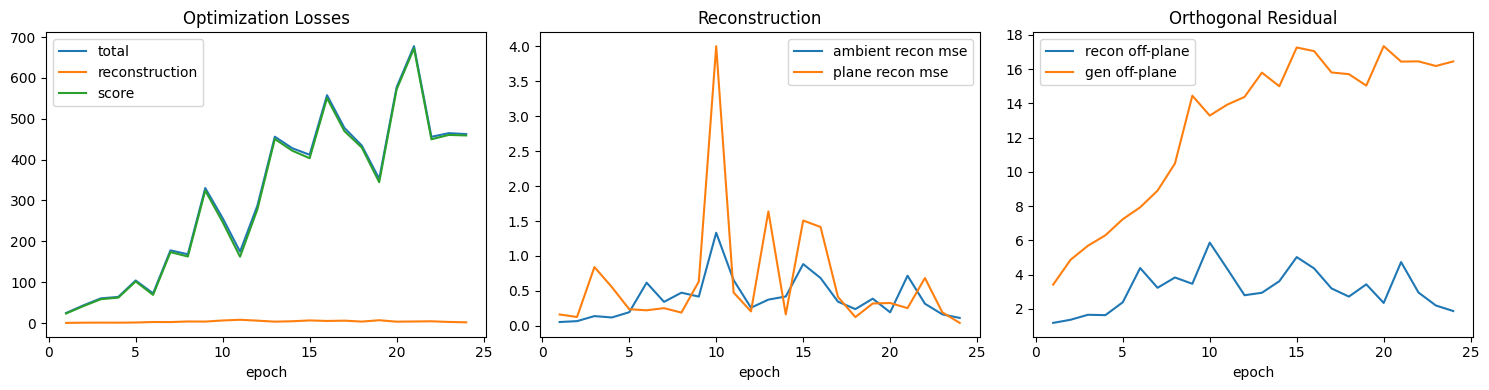

In [7]:
plot_training_curves(results["history"])

display(
    results["data_config"].dataset_config.visualize(
        points_by_class={
            "data": results["snapshot"]["x_true_hd"],
            "reconstruction": results["snapshot"]["x_recon_hd"],
            "model": results["snapshot"]["x_gen_hd"],
        },
    )
)
